In [1]:
import os
import math

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, precision_score, recall_score, roc_auc_score,
                             roc_curve, precision_recall_curve, confusion_matrix)
from sklearn.utils import shuffle

import warnings
# в sklearn 1.9 параметр probability у SVC помечен устаревшим; здесь он осознанно
# используется для получения predict_proba, поэтому глушим только это предупреждение
warnings.filterwarnings('ignore', message='The `probability` parameter was deprecated', category=FutureWarning)

**Содержание**
1. [Подготовка данных](#Подготовка-данных)
2. [Исследование задачи](#Исследование-задачи)
3. [Борьба с дисбалансом](#Борьба-с-дисбалансом) (upsampling, downsampling, взвешивание классов, подбор гиперпараметров RF / LogReg / SVC / KNN, Naive Bayes, LDA)
4. [Тестирование модели](#Тестирование-модели)

# Отток клиентов

Из «Бета-Банка» стали уходить клиенты. Каждый месяц. Немного, но заметно. Банковские маркетологи посчитали: сохранять текущих клиентов дешевле, чем привлекать новых.

Нужно спрогнозировать, уйдёт клиент из банка в ближайшее время или нет. Вам предоставлены исторические данные о поведении клиентов и расторжении договоров с банком. 

Постройте модель с предельно большим значением *F1*-меры. Чтобы сдать проект успешно, нужно довести метрику до 0.59. Проверьте *F1*-меру на тестовой выборке самостоятельно.

Дополнительно измеряйте *AUC-ROC*, сравнивайте её значение с *F1*-мерой.

Источник данных: [https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling](https://www.kaggle.com/barelydedicated/bank-customer-churn-modeling)

## Подготовка данных

In [2]:
def load_dataset(name, **kwargs):
    """Читает датасет из локальной папки datasets/, при её отсутствии — с code.s3.yandex.net."""
    local = os.path.join('datasets', name)
    source = local if os.path.exists(local) else 'https://code.s3.yandex.net/datasets/' + name
    return pd.read_csv(source, **kwargs)

df = load_dataset('Churn.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           9091 non-null   float64
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(3), int64(8), str(3)
memory usage: 1.1 MB


In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,9091.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,4.997690,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.894723,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,2.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


Не хочется терять около 10% данных удалением строк с пропусками, поэтому заполним пропуски в признаке `Tenure` медианой.

In [5]:
df['Tenure'] = df['Tenure'].fillna(df['Tenure'].median())

Удалим неинформативные для последующего анализа признаки:

In [6]:
df = df.drop(['Surname', 'RowNumber', 'CustomerId'], axis=1)

Выведем pairplot для количественных признаков:

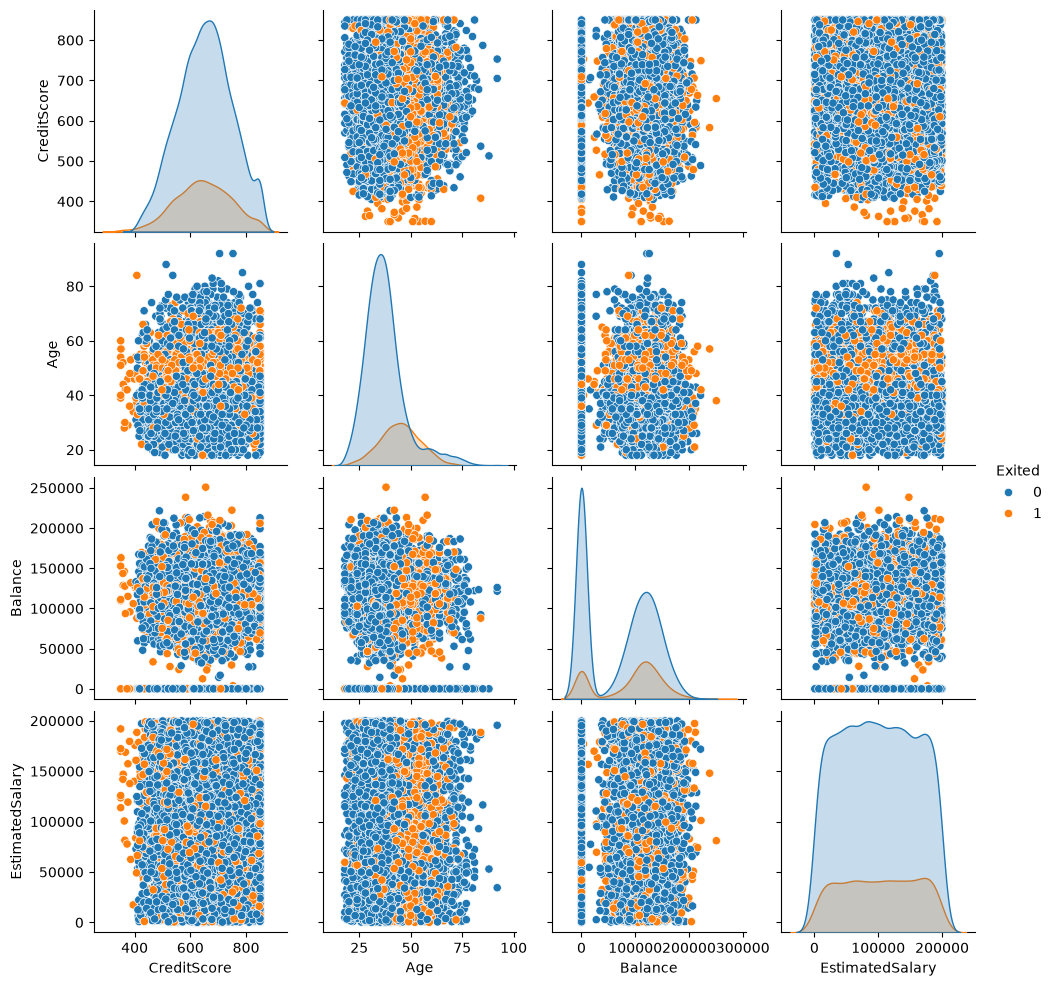

In [7]:
sns.pairplot(df[['CreditScore','Age', 'Balance', 'EstimatedSalary', 'Exited']], hue='Exited')

Воспользуемся техникой One Hot Encoding для перевода номинальных категориальных признаков в количественные:

In [8]:
df_ohe = pd.get_dummies(df, drop_first=True)
df_ohe.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2.0,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1.0,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8.0,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1.0,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2.0,125510.82,1,1,1,79084.10,0,False,True,False


Разделение на выборки:

In [9]:
target = df_ohe['Exited']
features = df_ohe.drop('Exited', axis=1)
features.shape, target.shape

((10000, 11), (10000,))

Разделим выборку на обучающую, валидационную и тестовую

In [10]:
features_train, features_valid, target_train, target_valid = train_test_split(
    features, target, test_size=0.4, random_state=12345)
features_valid, features_test, target_valid, target_test = train_test_split(
    features_valid, target_valid, test_size=0.5, random_state=12345)

Масштабируем численные признаки:

In [11]:
numeric = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
scaler.fit(features_train[numeric])
features_train[numeric] = scaler.transform(features_train[numeric])
features_train.shape

(6000, 11)

In [12]:
features_valid[numeric] = scaler.transform(features_valid[numeric])
features_valid.shape

(2000, 11)

In [13]:
features_test[numeric] = scaler.transform(features_test[numeric])
features_test.shape

(2000, 11)

## Исследование задачи

### Random Forest

Обучим и выведем метрику accuracy для модели Random Forest

In [14]:
model_rf = RandomForestClassifier(random_state=12345)
model_rf.fit(features_train, target_train)
model_rf.score(features_valid, target_valid)

0.8585

Выведем матрицу ошибок:

In [15]:
print(confusion_matrix(target_valid, model_rf.predict(features_valid)))

[[1524   58]
 [ 225  193]]


Произведем рассчет F-1 меры и метрики ROC-AUC:

In [16]:
probabilities = model_rf.predict_proba(features_valid)[:, 1]

In [17]:
f1_score(target_valid, model_rf.predict(features_valid))

0.5769805680119582

In [18]:
auc_roc = roc_auc_score(target_valid, probabilities)
auc_roc

0.840733672475638

Построим ROC-кривую функцией `ROC(model, X, y)`:
* model — обученная модель;
* X — валидационная выборка с признаками;
* y — правильные ответы на валидационной выборке.

In [19]:
def ROC(model, X, y):
    probabilities = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y, probabilities)

    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    # ROC-кривая случайной модели (диагональ)
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривая')
    plt.show()

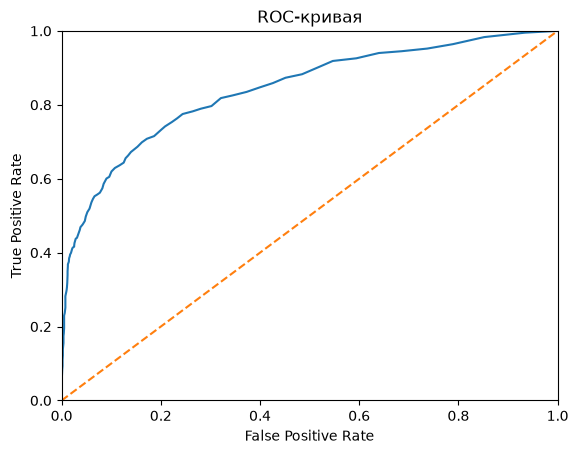

In [20]:
ROC(model_rf, features_valid, target_valid)

Построим кривую Precision-Recall функцией `PR(model, X, y)` (аргументы аналогичны `ROC`):

In [21]:
def PR(model, X, y):
    probabilities_valid = model.predict_proba(X)
    precision, recall, thresholds = precision_recall_curve(y, probabilities_valid[:, 1])

    plt.figure(figsize=(6, 6))
    plt.step(recall, precision, where='post')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.ylim([0.0, 1.05])
    plt.xlim([0.0, 1.0])
    plt.title('Кривая Precision-Recall')
    plt.show()

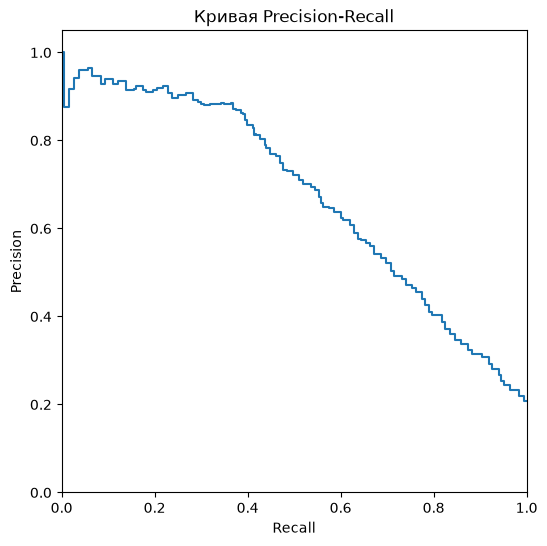

In [22]:
PR(model_rf, features_valid, target_valid)

## Борьба с дисбалансом

Покажем, что целевой признак имеет дисбаланс классов:

In [23]:
target.value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

### Upsampling

In [24]:
def upsample(features, target, repeat):
    features_0 = features[target==0]
    features_1 = features[target==1]
    target_0 =  target[target==0]
    target_1 =  target[target==1]
    features_upsampled = pd.concat( [features_0] + [features_1]*repeat)
    target_upsampled = pd.concat( [target_0] + [target_1]*repeat)
    features_upsampled, target_upsampled = shuffle(features_upsampled, target_upsampled, random_state=12345)
    return features_upsampled, target_upsampled

In [25]:
repeat = math.ceil(target[target==0].shape[0]/target[target==1].shape[0])
repeat

4

In [26]:
features_upsampled, target_upsampled = upsample(features_train, target_train, repeat)
features_upsampled.shape, target_upsampled.shape

((9588, 11), (9588,))

In [27]:
model_rf_up = RandomForestClassifier(random_state=12345)
model_rf_up.fit(features_upsampled, target_upsampled)
model_rf_up.score(features_valid, target_valid)

0.852

In [28]:
f1_score(target_valid, model_rf_up.predict(features_valid))

0.6084656084656085

F1-мера повысилась по сравнению с моделью без учёта дисбаланса.

In [29]:
roc_auc_score(target_valid, model_rf_up.predict_proba(features_valid)[:, 1])

0.8396471367477422

AUC-ROC также увеличилась.

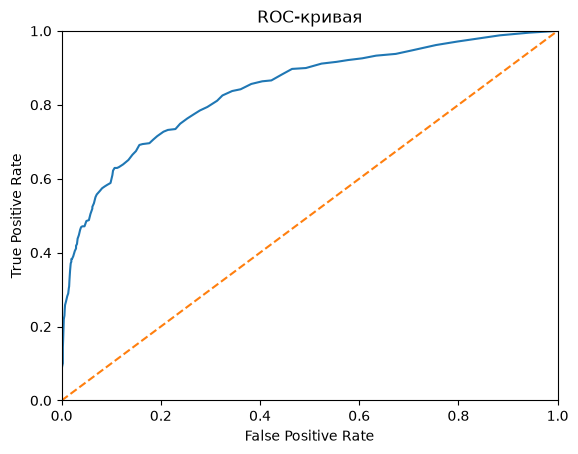

In [30]:
ROC(model_rf_up, features_valid, target_valid)

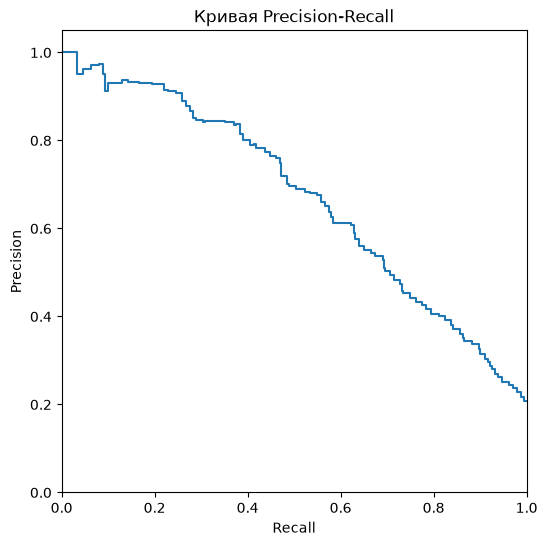

In [31]:
PR(model_rf_up, features_valid, target_valid)

### Downsampling

In [32]:
def downsample(features, target, fraction):
    features_0 = features[target==0]
    features_1 = features[target==1]
    target_0 =  target[target==0]
    target_1 =  target[target==1]
    features_downsampled = pd.concat( [features_0.sample(frac=fraction, random_state=12345)] + [features_1])
    target_downsampled = pd.concat( [target_0.sample(frac=fraction, random_state=12345)] + [target_1])
    features_downsampled, target_downsampled = shuffle(features_downsampled, target_downsampled, random_state=12345)
    return features_downsampled, target_downsampled

In [33]:
fraction = 1/repeat
features_downsampled, target_downsampled = downsample(features_train, target_train, fraction)

In [34]:
model_rf_down = RandomForestClassifier(random_state=12345)
model_rf_down.fit(features_downsampled, target_downsampled)
model_rf_down.score(features_valid, target_valid)

0.7725

In [35]:
f1_score(target_valid, model_rf_down.predict(features_valid))

0.5775301764159703

F1-мера ниже, чем при upsampling.

In [36]:
roc_auc_score(target_valid, model_rf_down.predict_proba(features_valid)[:, 1])

0.8452907711757269

AUC-ROC увеличилась по сравнению с моделью без учёта дисбаланса.

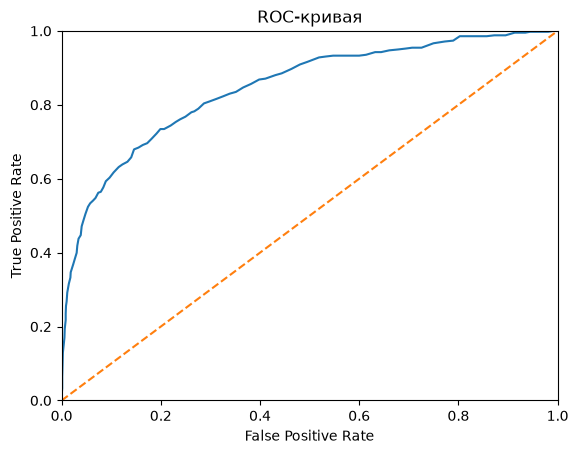

In [37]:
ROC(model_rf_down, features_valid, target_valid)

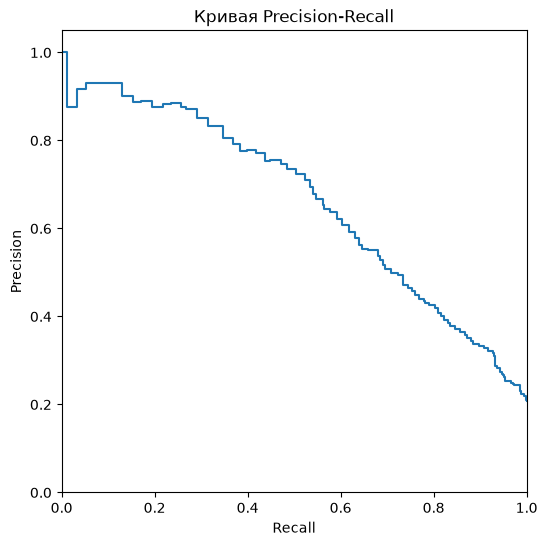

In [38]:
PR(model_rf_down, features_valid, target_valid)

### Взвешивание классов

In [39]:
model_rf_weighted = RandomForestClassifier(class_weight='balanced', random_state=12345)
model_rf_weighted.fit(features_train, target_train)
(model_rf_weighted.score(features_valid, target_valid),
 f1_score(target_valid, model_rf_weighted.predict(features_valid)),
 roc_auc_score(target_valid, model_rf_weighted.predict_proba(features_valid)[:, 1]))

(0.8425, 0.6096654275092936, 0.8413567103599708)

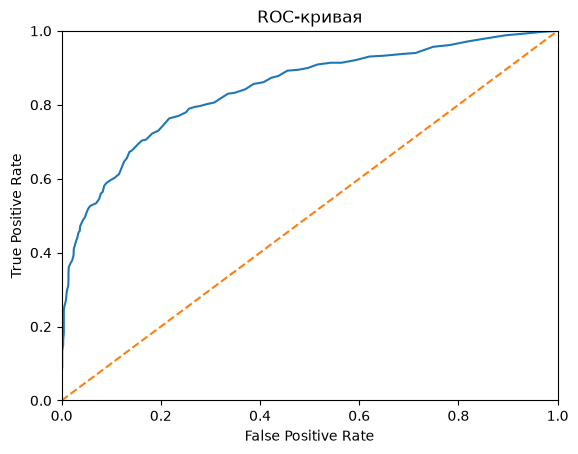

In [40]:
ROC(model_rf_weighted, features_valid, target_valid)

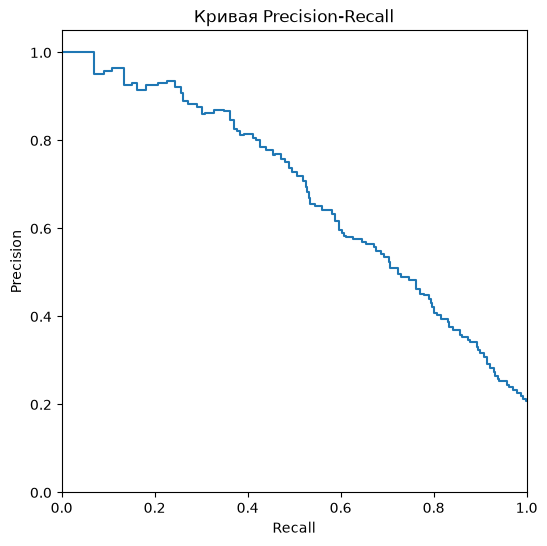

In [41]:
PR(model_rf_weighted, features_valid, target_valid)

### RF с подбором гиперпараметров

In [42]:
%%time
best_score = 0
for n_estimators in range(1, 100, 5):
    for criterion in ['gini', 'entropy']:
        for min_samples_split in range(2, 10, 2):
            model = RandomForestClassifier(n_estimators=n_estimators, criterion=criterion,
                                           min_samples_split=min_samples_split, n_jobs=4, random_state=12345)
            model.fit(features_upsampled, target_upsampled)
            score = f1_score(target_valid, model.predict(features_valid))
            if score > best_score:
                best_score = score
                best_params = (n_estimators, criterion, min_samples_split)
                best_model_RF = model
print(best_score, best_params)

0.623921085080148 (31, 'entropy', 8)
CPU times: user 52.3 s, sys: 1.2 s, total: 53.5 s
Wall time: 20.2 s


Для лучшей RF-модели AUC-ROC увеличилась:

In [43]:
roc_auc_score(target_valid, best_model_RF.predict_proba(features_valid)[:, 1])

0.8430587228328263

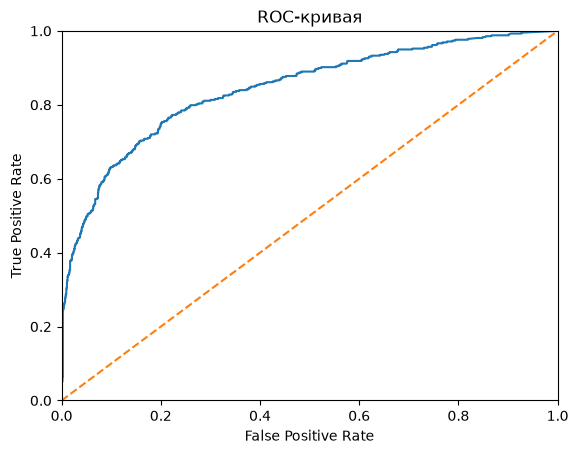

In [44]:
ROC(best_model_RF, features_valid, target_valid)

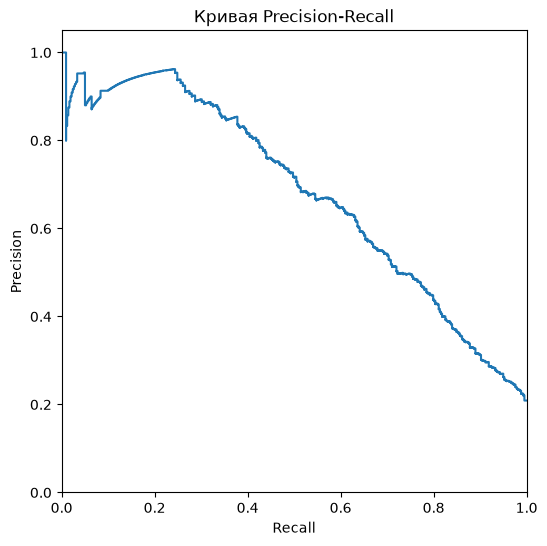

In [45]:
PR(best_model_RF, features_valid, target_valid)

Кривая P-R заметно сгладилась в сравнении с моделью RF без настройки гиперпараметров.

### LogReg с подбором гиперпараметров

In [46]:
model_logreg = LogisticRegression(random_state=12345, max_iter=1000)
model_logreg.fit(features_train, target_train)
model_logreg.score(features_valid, target_valid), f1_score(target_valid, model_logreg.predict(features_valid))

(0.802, 0.3310810810810811)

In [47]:
roc_auc_score(target_valid, model_logreg.predict_proba(features_valid)[:, 1])

0.7588011662301369

In [48]:
%%time
best_score = 0
for solver in ['lbfgs', 'liblinear', 'newton-cg']:
    for C in np.logspace(-4, 4, 9):
        for max_iter in [500, 1000]:
            model = LogisticRegression(random_state=12345, solver=solver, C=C, max_iter=max_iter)
            model.fit(features_upsampled, target_upsampled)
            score = f1_score(target_valid, model.predict(features_valid))
            if score > best_score:
                best_score = score
                best_params = (solver, C, max_iter)
                best_model_LogReg = model
print(best_score, best_params)

0.5163043478260869 ('liblinear', np.float64(0.001), 500)
CPU times: user 1.24 s, sys: 0 ns, total: 1.24 s
Wall time: 478 ms


In [49]:
roc_auc_score(target_valid, best_model_LogReg.predict_proba(features_valid)[:, 1])

0.7700990206812284

In [50]:
probabilities_one_valid = best_model_LogReg.predict_proba(features_valid)[:, 1]
for threshold in np.arange(0, 1, 0.05):
    predicted_valid = probabilities_one_valid > threshold
    precision = precision_score(target_valid, predicted_valid, zero_division=0)
    recall = recall_score(target_valid, predicted_valid)
    f1 = f1_score(target_valid, predicted_valid)
    print("Порог = {:.2f} | Точность = {:.3f}, Полнота = {:.3f}, F1-мера = {:.3f}".format(
        threshold, precision, recall, f1))

Порог = 0.00 | Точность = 0.209, Полнота = 1.000, F1-мера = 0.346
Порог = 0.05 | Точность = 0.209, Полнота = 1.000, F1-мера = 0.346
Порог = 0.10 | Точность = 0.209, Полнота = 1.000, F1-мера = 0.346
Порог = 0.15 | Точность = 0.209, Полнота = 1.000, F1-мера = 0.346
Порог = 0.20 | Точность = 0.211, Полнота = 1.000, F1-мера = 0.348


Порог = 0.25 | Точность = 0.218, Полнота = 0.998, F1-мера = 0.358
Порог = 0.30 | Точность = 0.233, Полнота = 0.988, F1-мера = 0.377
Порог = 0.35 | Точность = 0.257, Полнота = 0.938, F1-мера = 0.403
Порог = 0.40 | Точность = 0.293, Полнота = 0.885, F1-мера = 0.440
Порог = 0.45 | Точность = 0.342, Полнота = 0.789, F1-мера = 0.477
Порог = 0.50 | Точность = 0.415, Полнота = 0.682, F1-мера = 0.516
Порог = 0.55 | Точность = 0.464, Полнота = 0.543, F1-мера = 0.501
Порог = 0.60 | Точность = 0.497, Полнота = 0.404, F1-мера = 0.446
Порог = 0.65 | Точность = 0.514, Полнота = 0.270, F1-мера = 0.354
Порог = 0.70 | Точность = 0.500, Полнота = 0.148, F1-мера = 0.229
Порог = 0.75 | Точность = 0.451, Полнота = 0.077, F1-мера = 0.131
Порог = 0.80 | Точность = 0.333, Полнота = 0.019, F1-мера = 0.036
Порог = 0.85 | Точность = 0.200, Полнота = 0.002, F1-мера = 0.005
Порог = 0.90 | Точность = 0.000, Полнота = 0.000, F1-мера = 0.000
Порог = 0.95 | Точность = 0.000, Полнота = 0.000, F1-мера = 0.000


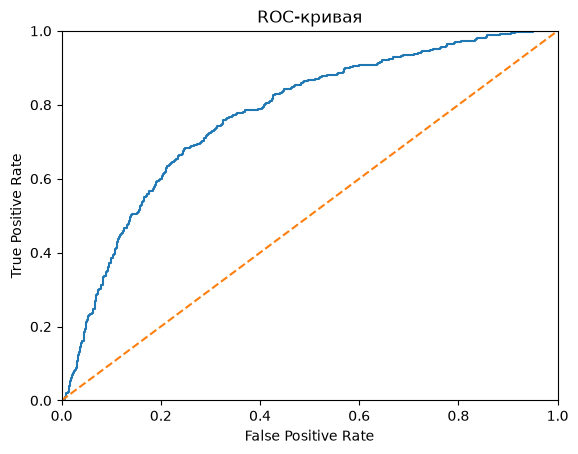

In [51]:
ROC(best_model_LogReg, features_valid, target_valid)

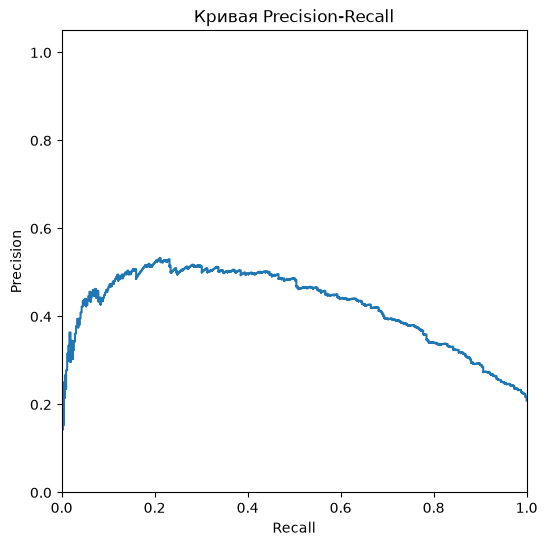

In [52]:
PR(best_model_LogReg, features_valid, target_valid)

### SVC с подбором гиперпараметров

In [53]:
model_svc = SVC(random_state=12345, probability=True)
model_svc.fit(features_train, target_train)
model_svc.score(features_valid, target_valid), f1_score(target_valid, model_svc.predict(features_valid))

(0.8585, 0.5428109854604201)

In [54]:
roc_auc_score(target_valid, model_svc.predict_proba(features_valid)[:, 1])

0.8250216248586068

In [55]:
%%time
best_score = 0
for C in [0.1, 1, 10]:
    for kernel in ['rbf', 'poly']:
        model = SVC(C=C, kernel=kernel, random_state=12345, probability=True)
        model.fit(features_upsampled, target_upsampled)
        score = f1_score(target_valid, model.predict(features_valid))
        if score > best_score:
            best_score = score
            best_params = (C, kernel)
            best_model_SVC = model
print(best_score, best_params)

0.5982404692082112 (1, 'rbf')
CPU times: user 45.2 s, sys: 928 ms, total: 46.1 s
Wall time: 46.1 s


In [56]:
roc_auc_score(target_valid, best_model_SVC.predict_proba(features_valid)[:, 1])

0.8402679062902632

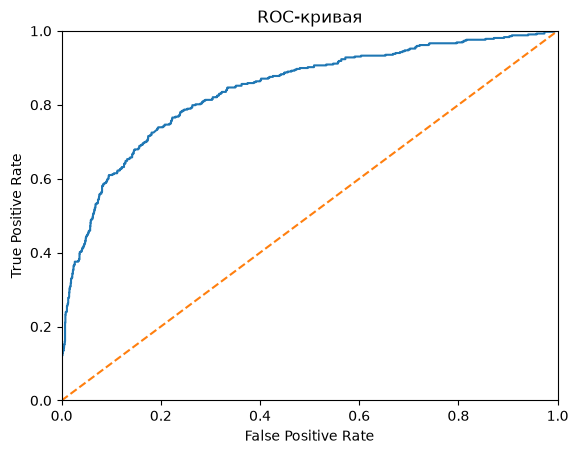

In [57]:
ROC(best_model_SVC, features_valid, target_valid)

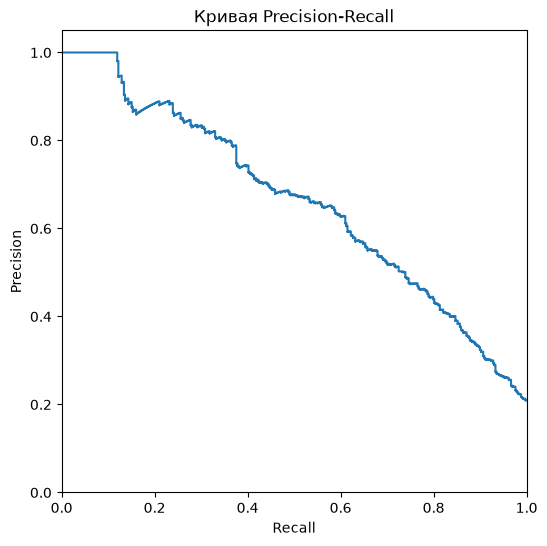

In [58]:
PR(best_model_SVC, features_valid, target_valid)

### KNN с подбором гиперпараметров

In [59]:
model_knn = KNeighborsClassifier()
model_knn.fit(features_train, target_train)
model_knn.score(features_valid, target_valid), f1_score(target_valid, model_knn.predict(features_valid))

(0.847, 0.5526315789473685)

In [60]:
roc_auc_score(target_valid, model_knn.predict_proba(features_valid)[:, 1])

0.7933041574168728

In [61]:
%%time
best_score = 0
for n_neighbors in range(1, 20, 2):
    for algorithm in ['auto', 'ball_tree', 'kd_tree', 'brute']:
        for metric in ['euclidean', 'manhattan', 'chebyshev']:
            model = KNeighborsClassifier(n_neighbors=n_neighbors, algorithm=algorithm, metric=metric)
            model.fit(features_upsampled, target_upsampled)
            score = f1_score(target_valid, model.predict(features_valid))
            if score > best_score:
                best_score = score
                best_params = (n_neighbors, algorithm, metric)
                best_model_KNN = model
print(best_score, best_params)

0.5687885010266941 (9, 'auto', 'manhattan')
CPU times: user 12.1 s, sys: 8.29 ms, total: 12.1 s
Wall time: 8.7 s


In [62]:
roc_auc_score(target_valid, best_model_KNN.predict_proba(features_valid)[:, 1])

0.793778240855558

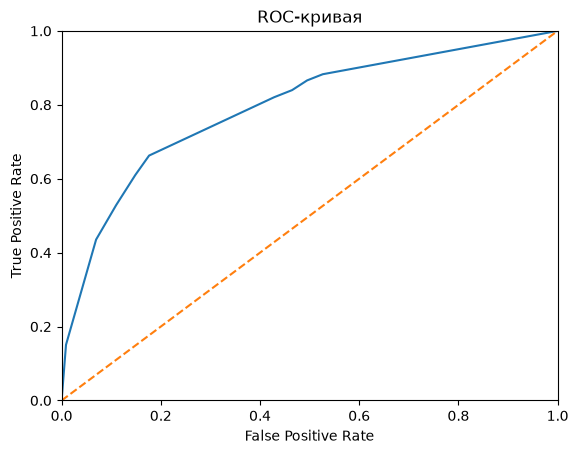

In [63]:
ROC(best_model_KNN, features_valid, target_valid)

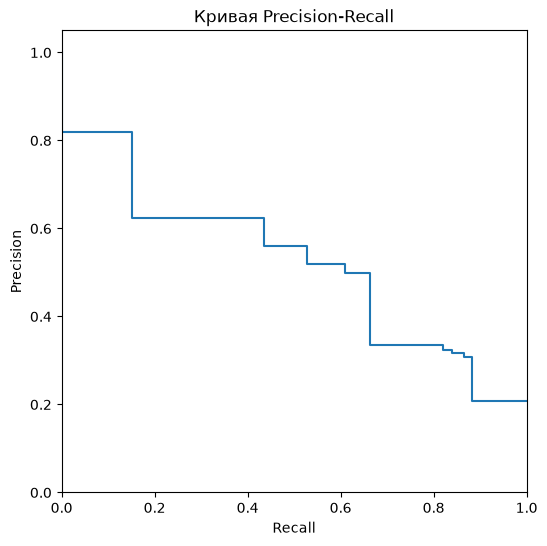

In [64]:
PR(best_model_KNN, features_valid, target_valid)

### Naive Bayes

In [65]:
model_nb = GaussianNB()
model_nb.fit(features_train, target_train)
model_nb.score(features_valid, target_valid), f1_score(target_valid, model_nb.predict(features_valid))

(0.808, 0.42686567164179107)

In [66]:
roc_auc_score(target_valid, model_nb.predict_proba(features_valid)[:, 1])

0.7849430494982429

In [67]:
model_nb_up = GaussianNB()
model_nb_up.fit(features_upsampled, target_upsampled)
model_nb_up.score(features_valid, target_valid), f1_score(target_valid, model_nb_up.predict(features_valid))

(0.714, 0.5051903114186851)

In [68]:
roc_auc_score(target_valid, model_nb_up.predict_proba(features_valid)[:, 1])

0.7849430494982429

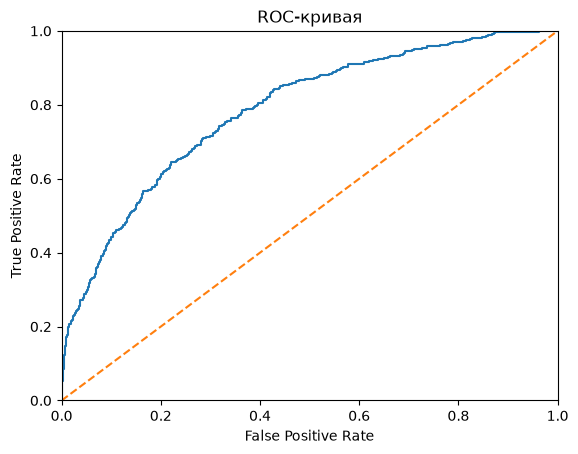

In [69]:
ROC(model_nb_up, features_valid, target_valid)

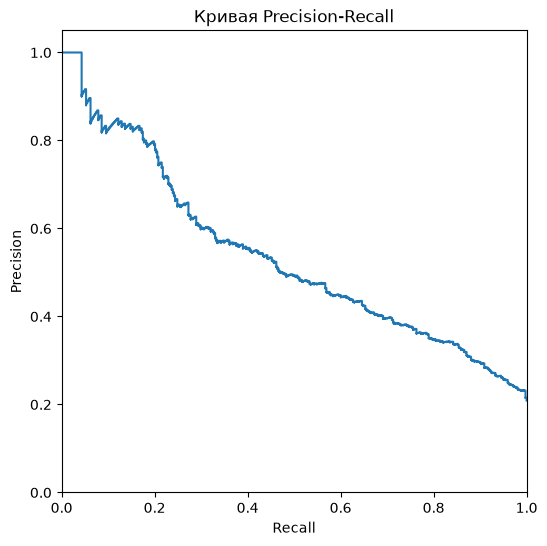

In [70]:
PR(model_nb_up, features_valid, target_valid)

### LDA

In [71]:
model_lda = LinearDiscriminantAnalysis()
model_lda.fit(features_train, target_train)
model_lda.score(features_valid, target_valid), f1_score(target_valid, model_lda.predict(features_valid))

(0.7975, 0.34782608695652173)

In [72]:
roc_auc_score(target_valid, model_lda.predict_proba(features_valid)[:, 1])

0.7613825392120688

In [73]:
model_lda_up = LinearDiscriminantAnalysis()
model_lda_up.fit(features_upsampled, target_upsampled)
model_lda_up.score(features_valid, target_valid), f1_score(target_valid, model_lda_up.predict(features_valid))

(0.7035, 0.4883520276100086)

In [74]:
roc_auc_score(target_valid, model_lda_up.predict_proba(features_valid)[:, 1])

0.7632592140044399

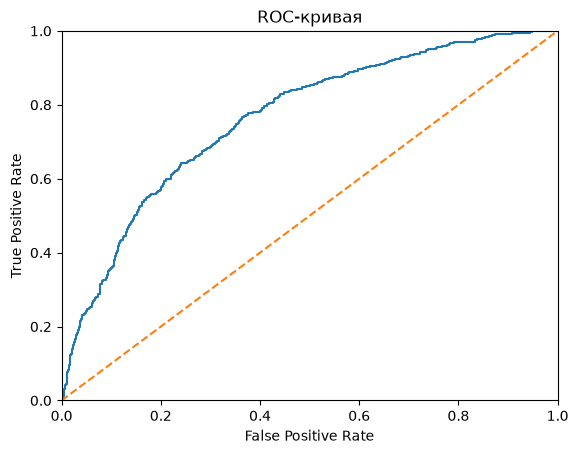

In [75]:
ROC(model_lda_up, features_valid, target_valid)

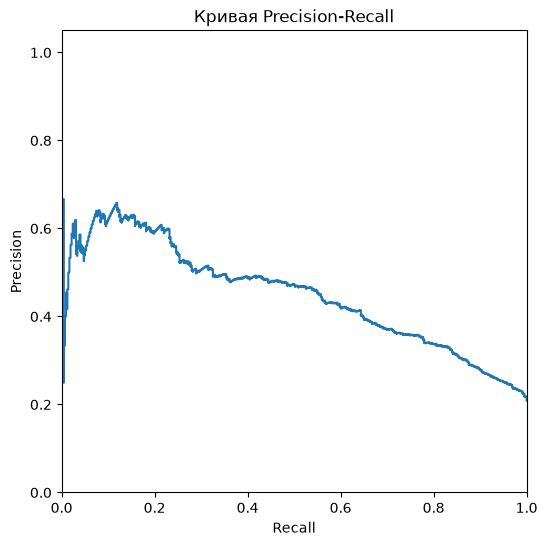

In [76]:
PR(model_lda_up, features_valid, target_valid)

In [77]:
models = {
    'RF': model_rf, 'RF_upsampled': model_rf_up, 'RF_downsampled': model_rf_down,
    'RF_weighted': model_rf_weighted, 'best_model_RF': best_model_RF,
    'best_model_LogReg': best_model_LogReg, 'best_model_SVC': best_model_SVC,
    'best_model_KNN': best_model_KNN, 'Naive_Bayes': model_nb_up, 'LDA': model_lda_up,
}
print("Модель  {:<12}".format(' '), 'Accuracy', 'F-1', 'AUC_ROC')
for name, model in models.items():
    print("{:<20}".format(name), "  {:.2f}, {:.2f}, {:.2f}".format(
        model.score(features_valid, target_valid),
        f1_score(target_valid, model.predict(features_valid)),
        roc_auc_score(target_valid, model.predict_proba(features_valid)[:, 1])))

Модель               Accuracy F-1 AUC_ROC
RF                     0.86, 0.58, 0.84
RF_upsampled           0.85, 0.61, 0.84


RF_downsampled         0.77, 0.58, 0.85
RF_weighted            0.84, 0.61, 0.84
best_model_RF          0.85, 0.62, 0.84
best_model_LogReg      0.73, 0.52, 0.77


best_model_SVC         0.79, 0.60, 0.84


best_model_KNN         0.79, 0.57, 0.79
Naive_Bayes            0.71, 0.51, 0.78
LDA                    0.70, 0.49, 0.76


## Тестирование модели

Для тестирования оставим только модели с F1-мерой на валидации больше 0.55:

In [78]:
for name in ['best_model_RF', 'RF_upsampled', 'RF_downsampled', 'RF_weighted', 'best_model_SVC', 'best_model_KNN']:
    model = models[name]
    print("Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): {:<20}".format(name),
          "  {:.2f}, {:.2f}, {:.2f}".format(
              model.score(features_test, target_test),
              f1_score(target_test, model.predict(features_test)),
              roc_auc_score(target_test, model.predict_proba(features_test)[:, 1])))

Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): best_model_RF          0.84, 0.60, 0.84
Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): RF_upsampled           0.84, 0.59, 0.85
Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): RF_downsampled         0.77, 0.58, 0.84
Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): RF_weighted            0.84, 0.60, 0.85


Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): best_model_SVC         0.80, 0.61, 0.85


Качество модели на тестовой выборке (accuracy, F-1, AUC_ROC): best_model_KNN         0.78, 0.55, 0.79


### Вывод:
Проведены преобразование категориальных признаков (One Hot Encoding) и масштабирование числовых.
Исследованы модели классификации с учётом и без учёта дисбаланса классов (upsampling, downsampling, взвешивание классов), подсчитаны метрики accuracy, F1 и AUC-ROC.

Требуемое значение F1 ≥ 0.59 на тестовой выборке достигнуто моделями с учётом дисбаланса:
- **SVC с подбором гиперпараметров: F1 = 0.61, AUC-ROC = 0.85** — лучшая модель;
- Random Forest с подбором гиперпараметров и RF со взвешиванием классов: F1 = 0.60, AUC-ROC = 0.84–0.85.